Average Headline Length: 80.02 characters


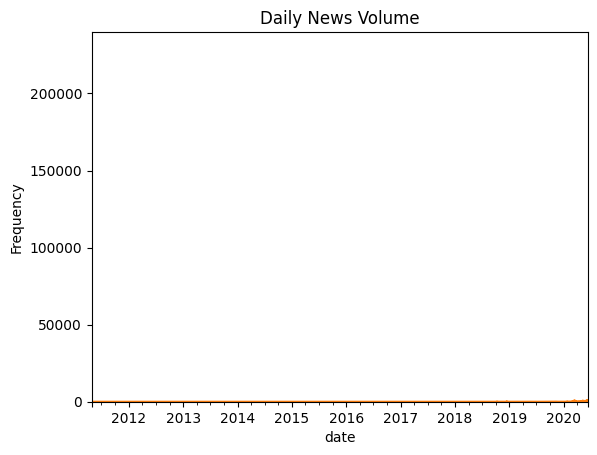

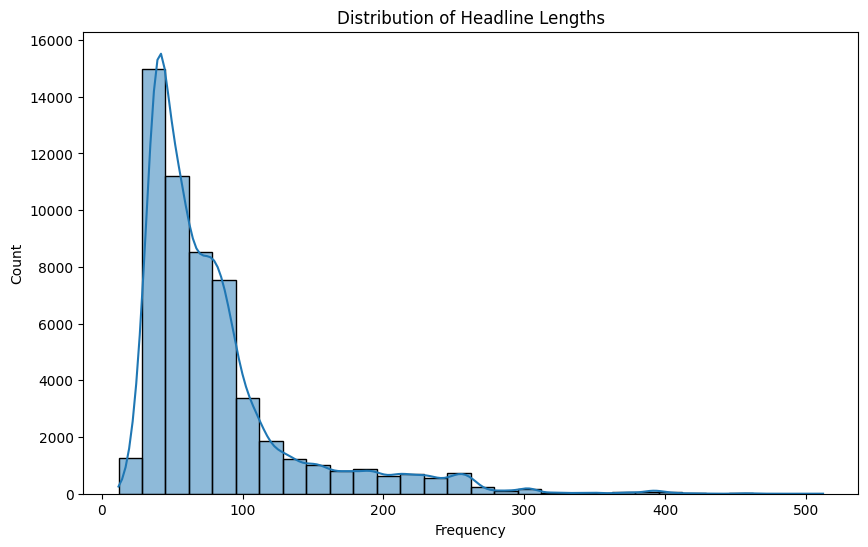

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#1. Load the Financial News Dataset
df_news = pd.read_csv('../data/raw/newsData/raw_analyst_ratings.csv')

#Load the stock data (for Task 2 progress)
df_stocks = pd.read_csv('../data/raw/yfinance_data/Data/AAPL.csv')

#Descriptive statistics: Headline Length
df_news['headline_len'] = df_news['headline'].apply(len)
df_news['headline_len'].plot(kind='hist', bins=50, title='Headline Length Distribution')

df_news['publisher'].value_counts().head(10).plot(kind='bar', title='Top 10 Publishers')
df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce', utc=True)
df_news = df_news.dropna(subset=['date'])
df_news.set_index('date').resample('D').size().plot(title='Daily News Volume')
print(f"Average Headline Length: {df_news['headline_len'].mean():.2f} characters")

#3. Simple Visualization for Task 1
plt.figure(figsize=(10,6))
sns.histplot(df_news['headline_len'], bins=30, kde=True)
plt.title('Distribution of Headline Lengths')
plt.xlabel('Frequency')
plt.show()

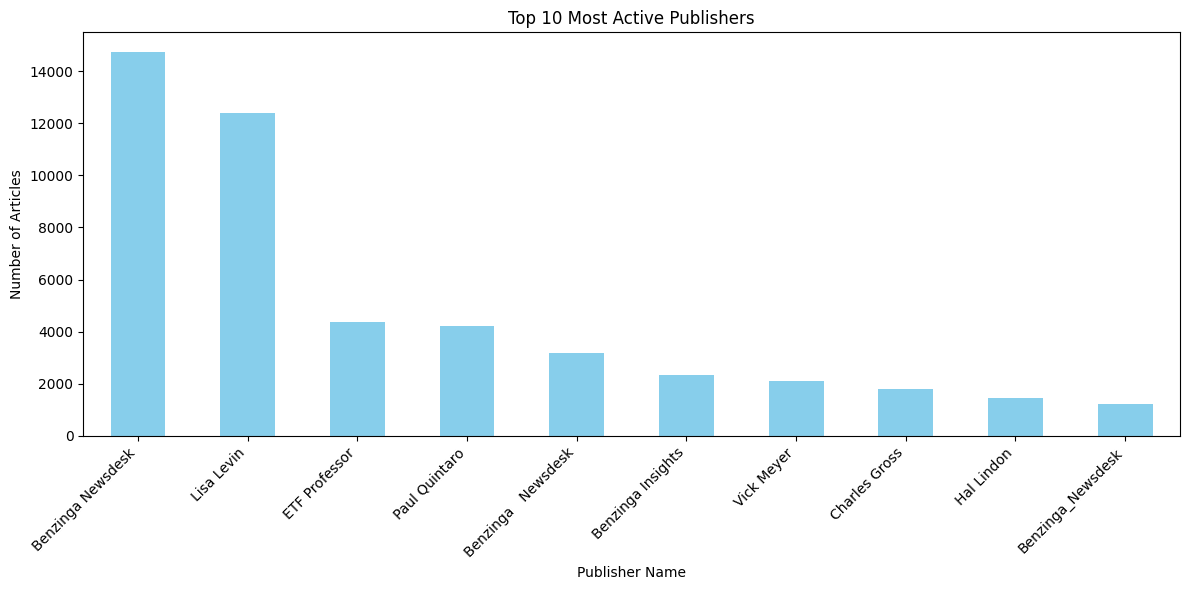

In [8]:
#count articles per publisher and plot top 10
top_10_publishers = df_news['publisher'].value_counts().head(10)
plt.figure(figsize=(12, 6))
top_10_publishers.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Active Publishers')
plt.xlabel('Publisher Name')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

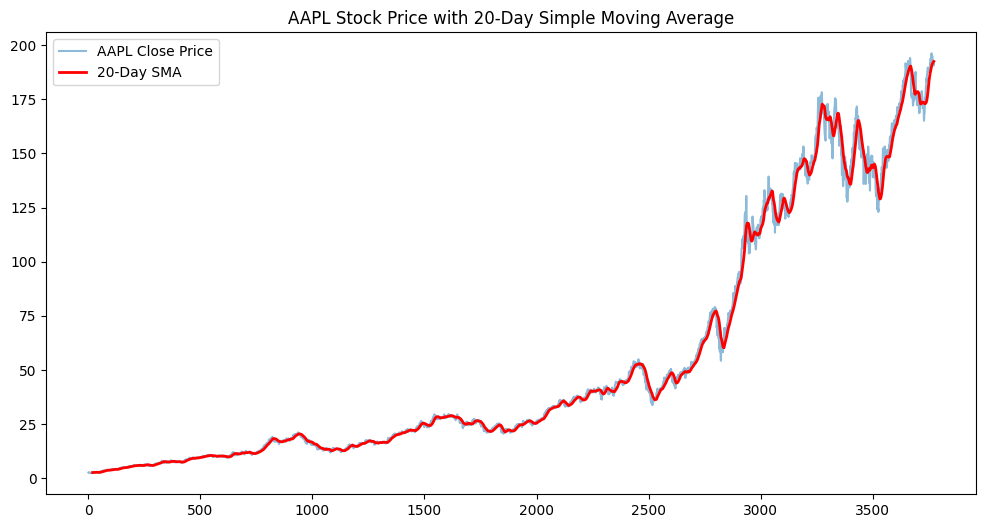

In [9]:
#Task 2: Calculate a 20-day Simple Moving Average (SMA) for AAPL
df_stocks['SMA_20'] = df_stocks['Close'].rolling(window=20).mean()

#Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_stocks['Close'], label='AAPL Close Price', alpha=0.5)
plt.plot(df_stocks['SMA_20'], label='20-Day SMA', color='red', linewidth=2)
plt.title('AAPL Stock Price with 20-Day Simple Moving Average')
plt.legend()
plt.show()